First, mount your Google Drive to access your files.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [44]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

After mounting, your Google Drive files will typically be accessible under `/content/gdrive/MyDrive/`. You'll need to specify the correct path to your SQLite database file.

Now, let's connect to your SQLite database.

In [45]:

base_path = "/content/drive/Othercomputers/My laptop/NUS/11_IT5006 Fundamentals of Data Analytics/03_Project/IT5006_Project-Data/Olist_CSV"

files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

# Read directly into your all_data dictionary
all_data = {name: pd.read_csv(os.path.join(base_path, filename)) for name, filename in files.items()}


In [60]:
# Get a general idea overview of no. row, columns, and column names
for title, data in all_data.items():
  print(f"Dataset Name: {title}\n   Row Count: {data.shape[0]}\n   Column Count: Row Count: {data.shape[1]}\n   Column Names:{", ".join(data.columns)}")

Dataset Name: customers
   Row Count: 99441
   Column Count: Row Count: 5
   Column Names:customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state
Dataset Name: geolocation
   Row Count: 1000163
   Column Count: Row Count: 5
   Column Names:geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state
Dataset Name: orders
   Row Count: 99441
   Column Count: Row Count: 8
   Column Names:order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
Dataset Name: order_items
   Row Count: 112650
   Column Count: Row Count: 7
   Column Names:order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value
Dataset Name: order_payments
   Row Count: 103886
   Column Count: Row Count: 5
   Column Names:order_id, payment_sequential, payment_type, payment_installments, payment_value
Dataset N

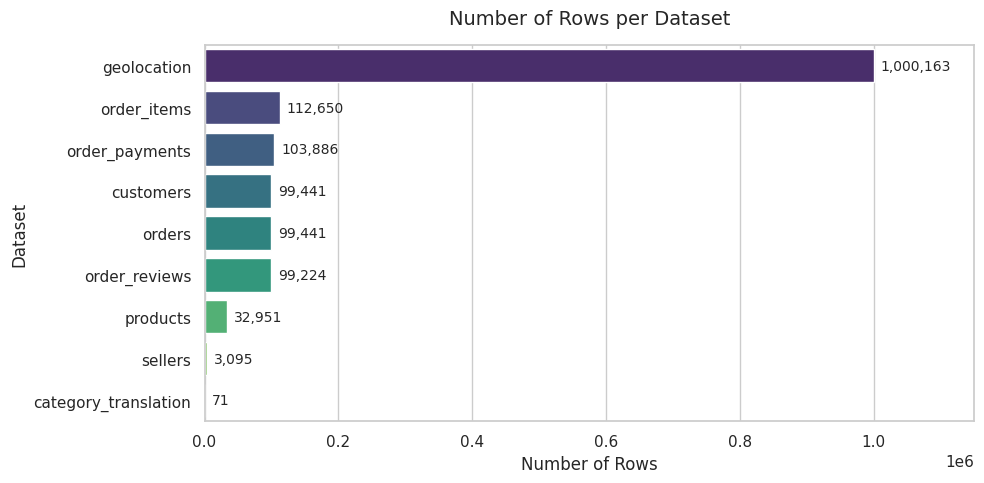

In [47]:

# Plot no. rows per dataset (written by AI)
# 1. Extract dataset names and row counts into a DataFrame
df_counts = pd.DataFrame(
    [{"title": title, "row_count": len(df)} for title, df in all_data.items()]
).sort_values("row_count", ascending=False)

# 2. Set plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 3. Create horizontal bar plot
ax = sns.barplot(
    data=df_counts,
    x="row_count",
    y="title",
    hue="title",
    palette="viridis",
    legend=False,
)

# 4. Format labels and titles
plt.title("Number of Rows per Dataset", fontsize=14, pad=15)
plt.xlabel("Number of Rows", fontsize=12)
plt.ylabel("Dataset", fontsize=12)

# Optional: Add direct data labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

# Adjust right margin so labels don't get clipped
plt.xlim(0, df_counts["row_count"].max() * 1.15)
plt.tight_layout()
plt.show()

In [48]:
groupby_column_names = {}
for dataset_name, dataset in all_data.items():
  for column_name in dataset.columns:
    if column_name not in groupby_column_names:
      groupby_column_names[column_name] = []
    groupby_column_names[column_name].append(dataset_name)

dataset_columns_without_repeats = {}
print("The following columns are found in multiple datasets:")
for column_name, datasets_names in groupby_column_names.items():
  if len(datasets_names) > 1:
    print(f"   Column name: '{column_name}'\n     Datasets: {', '.join(datasets_names)}")
  else:
    datasets_name = datasets_names[0]
    if datasets_name not in dataset_columns_without_repeats:
      dataset_columns_without_repeats[datasets_name] = []
    dataset_columns_without_repeats[datasets_name].append(column_name)

print("\nThe following columns are not found in multiple datasets:")
for dataset_name, column_names in dataset_columns_without_repeats.items():
  print(f"   Dataset: {dataset_name}\n     Columns: {', '.join(column_names)}")

The following columns are found in multiple datasets:
   Column name: 'customer_id'
     Datasets: customers, orders
   Column name: 'order_id'
     Datasets: orders, order_items, order_payments, order_reviews
   Column name: 'product_id'
     Datasets: order_items, products
   Column name: 'seller_id'
     Datasets: order_items, sellers
   Column name: 'product_category_name'
     Datasets: products, category_translation

The following columns are not found in multiple datasets:
   Dataset: customers
     Columns: customer_unique_id, customer_zip_code_prefix, customer_city, customer_state
   Dataset: geolocation
     Columns: geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state
   Dataset: orders
     Columns: order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
   Dataset: order_items
     Columns: order_item_id, shipping_limit_date, price, fr

In [57]:
for name, df in all_data.items():
  print(f"\n########## Dataset Name: {name} ##########")
  print(df.describe())


########## Dataset Name: customers ##########
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

########## Dataset Name: geolocation ##########
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054

In [63]:
# Merge product category names in orders with translated values
import pandas as pd

merged_products = pd.merge(
    all_data["products"],
    all_data["category_translation"],
    on='product_category_name',
    how='left'
)
merged_products['product_category_name'] = merged_products['product_category_name_english']
merged_products = merged_products.drop(columns=['product_category_name_english'])
all_data["products"] = merged_products
merged_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Number of unique categories:71

Top 10 categories by count: 
product_category_name
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: product_id, dtype: int64

Bottom 10 categories by count: 
product_category_name
fashion_sport                        19
flowers                              14
diapers_and_hygiene                  12
furniture_mattress_and_upholstery    10
la_cuisine                           10
tablets_printing_image                9
home_comfort_2                        5
fashion_childrens_clothes             5
security_and_services                 2
cds_dvds_musicals                     1
Name: product_id, dtype: int64


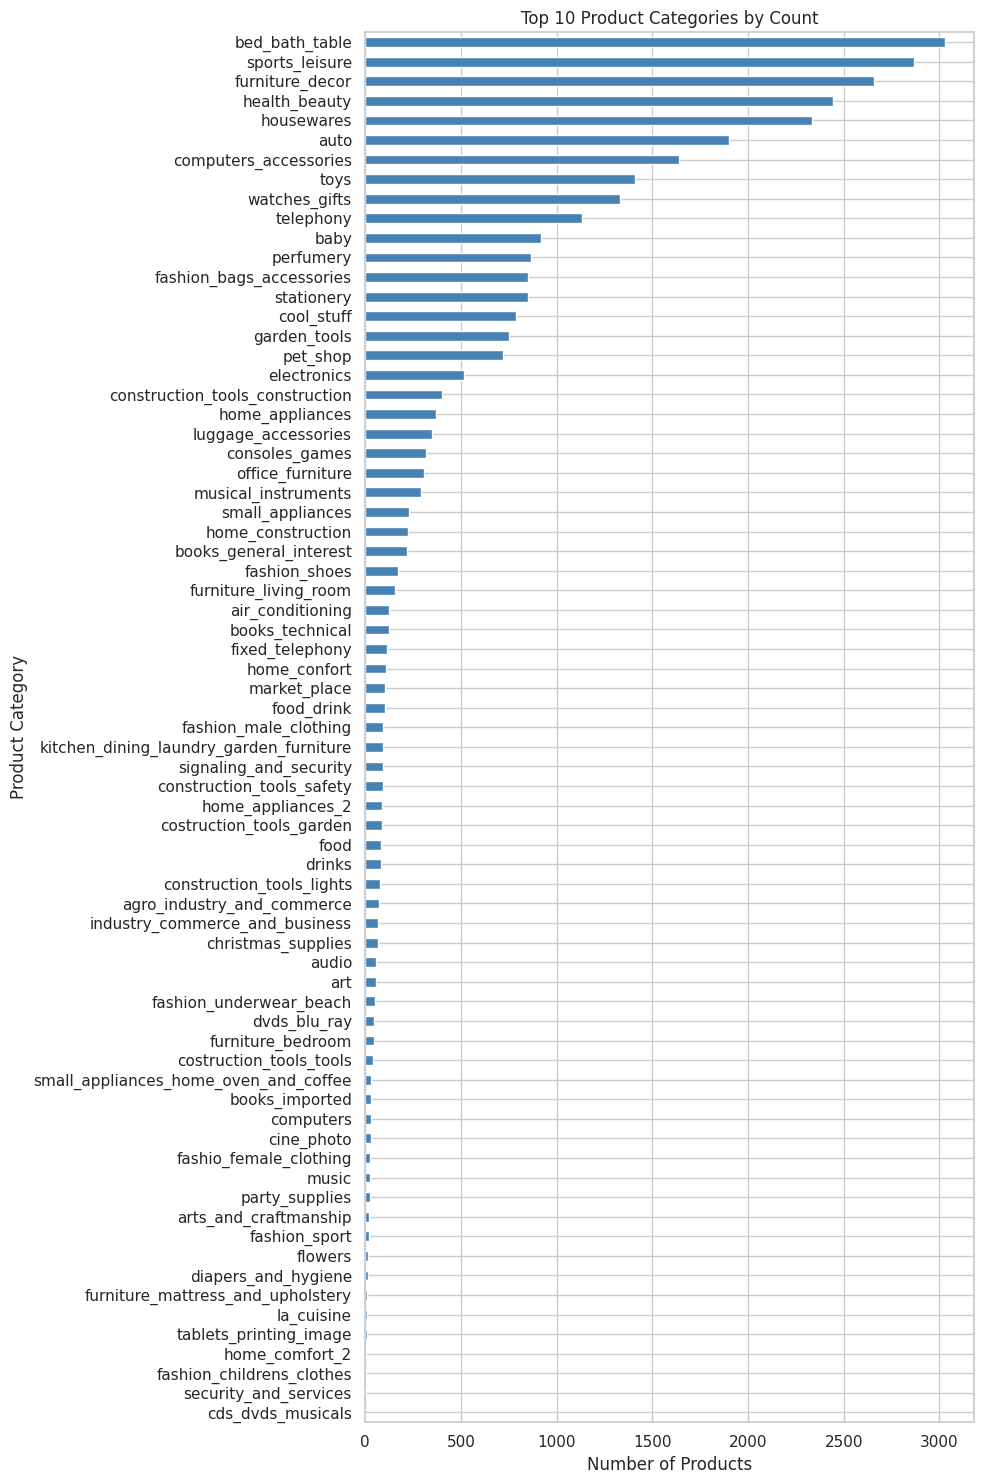

In [80]:
# See distribution of product in categories
products = all_data["products"]
category_counts = (
    products.groupby('product_category_name')['product_id']
    .count()
    .sort_values(ascending=False)
)
print(f"Number of unique categories:{category_counts.shape[0]}")
print("\nTop 10 categories by count: ")
print(category_counts.head(10))
print("\nBottom 10 categories by count: ")
print(category_counts.tail(10))


# Select top 10 categories and invert order so the largest is at the top
top_10 = category_counts.sort_values(ascending=True)

plt.figure(figsize=(10, 15))
top_10.plot(kind='barh', color='steelblue')

plt.title('Top 10 Product Categories by Count')
plt.xlabel('Number of Products')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [ ]:
# See distribution of spending by category
# TODO:

In [106]:
# See payment by installments
payment = all_data["order_payments"]
payment_by_installments_counts = (
    payment.groupby('payment_installments')['order_id']
    .count()
    .sort_values(ascending=False)
)
payment_by_installments_counts.head(10)

# Do note that payment by installment would natually have more entries cos 1 order generates more entries



,order_id
payment_installments,
1,52546
2,12413
3,10461
4,7098
10,5328
5,5239
8,4268
6,3920
7,1626


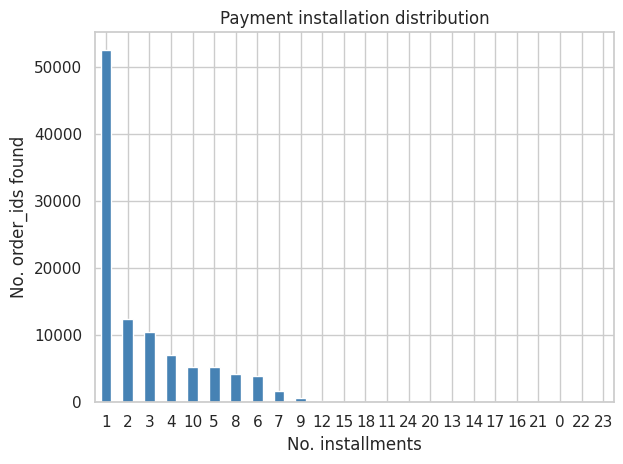

In [103]:
# Visualise payments
payment_by_installments_counts.plot(kind='bar', color='steelblue')
plt.title('Payment installation distribution')
plt.xlabel('No. installments')
plt.ylabel('No. order_ids found')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

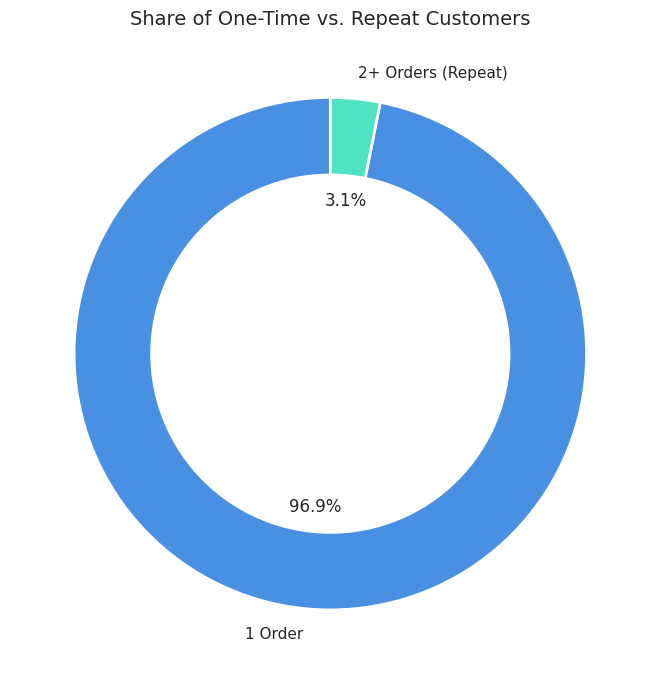

In [145]:
# Visualise Customers
customers = all_data["customers"]
customer_orders_df = (
    customers.groupby('customer_unique_id', as_index=False)['customer_id']
    .count()
    .rename(columns={
        'customer_id': 'no_orders'
    })
    .sort_values(by='no_orders', ascending=False)
)
customer_orders_df.head(20)

order_no_dist = (
    customer_orders_df.groupby('no_orders', as_index=False)['customer_unique_id']
    .count()
    .rename(columns={'customer_unique_id': 'customer_count'})
    .sort_values(by='no_orders')
)

order_no_dist.head(20)

# Visualise
# Segment into 1 order vs. 2+ orders
one_time = (customer_orders_df['no_orders'] == 1).sum()
repeat = (customer_orders_df['no_orders'] > 1).sum()

plt.figure(figsize=(7, 7))
plt.pie(
    [one_time, repeat],
    labels=['1 Order', '2+ Orders (Repeat)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4a90e2', '#50e3c2'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Draw inner circle for donut chart style
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Share of One-Time vs. Repeat Customers', fontsize=14)
plt.tight_layout()
plt.show()

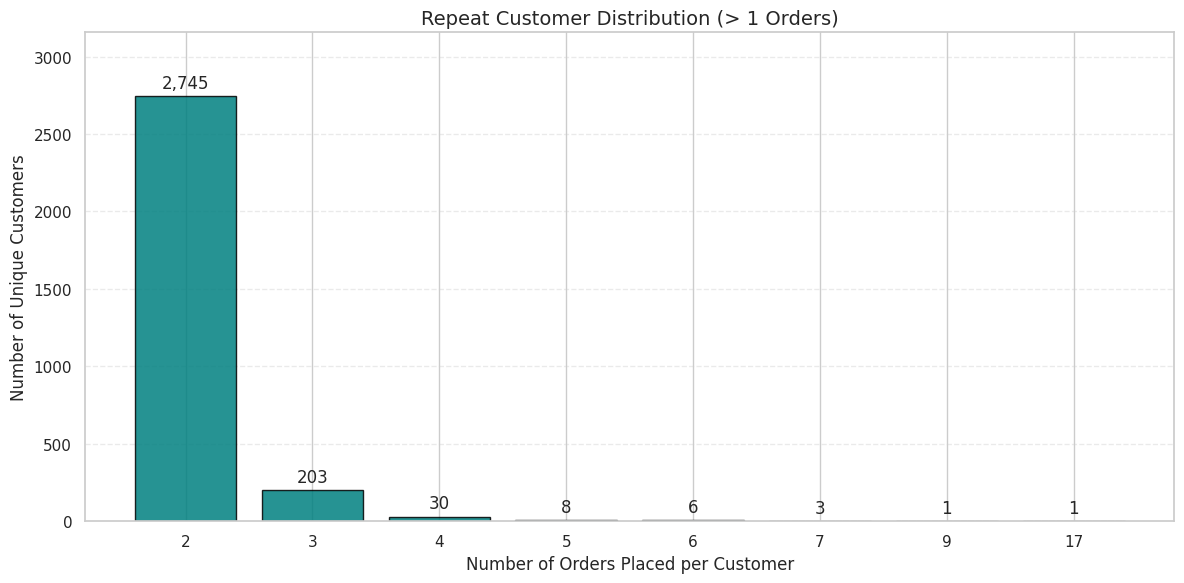

In [146]:
# Filter to customers who made more than 1 purchase
repeat_orders_dist = order_no_dist[order_no_dist['no_orders'] > 1].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    repeat_orders_dist['no_orders'].astype(str),
    repeat_orders_dist['customer_count'],
    color='teal',
    edgecolor='black',
    alpha=0.85
)

# Display counts directly above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='{:,.0f}')

ax.margins(y=0.15)
plt.title('Repeat Customer Distribution (> 1 Orders)', fontsize=14)
plt.xlabel('Number of Orders Placed per Customer', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

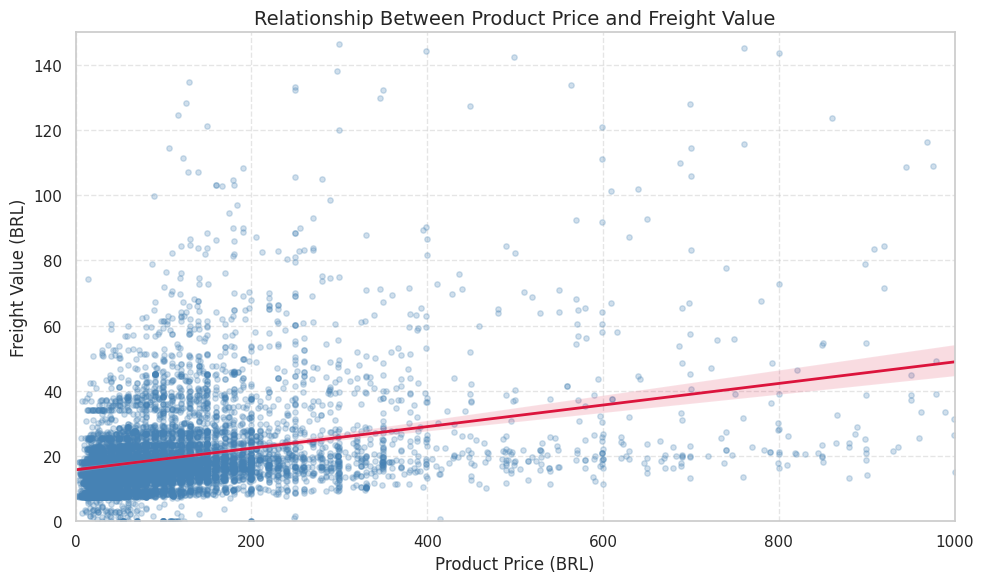

In [112]:
# See Product Prive vs Freight Value Distribution (AI)
order_items = all_data["order_items"]
sample_df = order_items.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))

# Scatter plot with fitted regression trend line
sns.regplot(
    data=sample_df,
    x='price',
    y='freight_value',
    scatter_kws={'alpha': 0.25, 'color': 'steelblue', 's': 15},
    line_kws={'color': 'crimson', 'linewidth': 2}
)

# Limit view to remove extreme tail outliers for clearer trend inspection
plt.xlim(0, 1000)
plt.ylim(0, 150)

plt.title('Relationship Between Product Price and Freight Value', fontsize=14)
plt.xlabel('Product Price (BRL)', fontsize=12)
plt.ylabel('Freight Value (BRL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [117]:
orders = all_data["orders"]
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


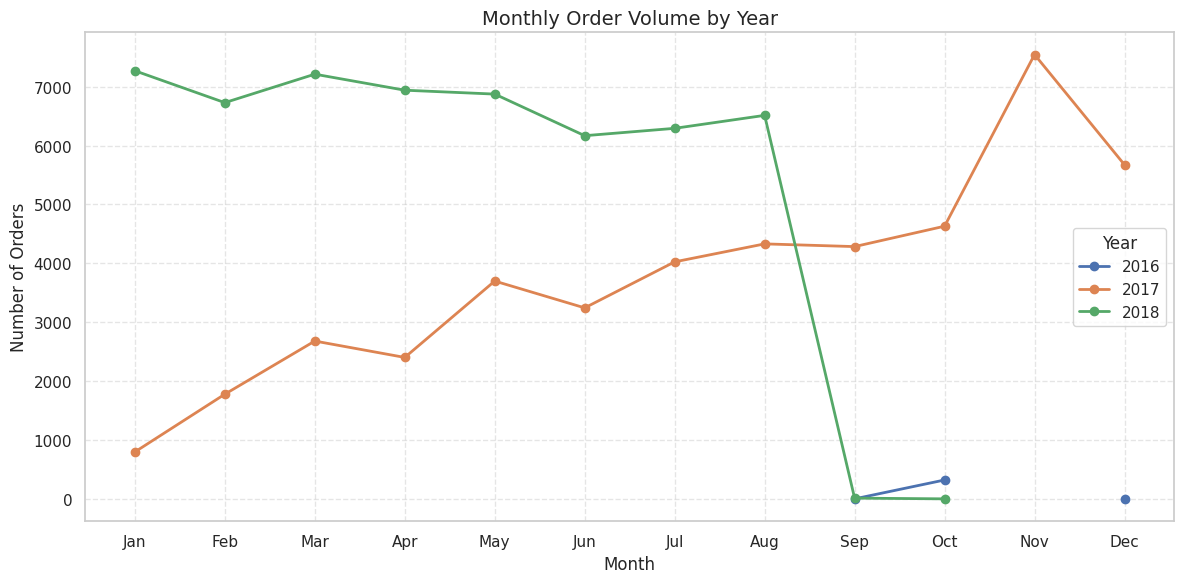

In [123]:
# See Order Seasonality (AI)
# 1. Convert timestamp using the specified datetime format
orders = all_data["orders"]
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    format='%Y-%m-%d %H:%M:%S'
)

orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month

# 3. Aggregate order counts by year and month, then unstack to create year columns
monthly_year_pivot = (
    orders.groupby(['month', 'year'])['order_id']
    .count()
    .unstack(level='year')
)
monthly_year_pivot
# 4. Plot each year as an individual line
plt.figure(figsize=(12, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for year in monthly_year_pivot.columns:
    plt.plot(
        monthly_year_pivot.index,
        monthly_year_pivot[year],
        marker='o',
        linewidth=2,
        label=str(year)
    )

plt.title('Monthly Order Volume by Year', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=month_names)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Conclusion: Only data from end Oct 2016 to Oct 2018 we don't really have that good of a multi year data